# Spam Model Evaluation

## Project overview

The goal of this project is to evaluate and compare several machine learning
classification models for detecting spam messages.

The models will be trained on the same dataset and compared using accuracy,
precision, recall, F1-score, and confusion matrices. The final goal is to
select the most reliable model and explain the reasons for that decision.

## 1. Importing Libraries

In this section, we import all the necessary Python libraries that will be used
for data manipulation, preprocessing, machine learning, evaluation, and
visualization.

In [1]:
# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Train/Test Split
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## 2. Loading the Dataset

The dataset is loaded into a Pandas DataFrame in order to inspect its structure
and identify potential issues before training machine learning models.

In [2]:
# Load the dataset
df = pd.read_csv("messages.csv")

## 3. Initial Data Exploration

Before cleaning the data, we inspect the dataset to understand its structure,
check for missing values, and analyze the distribution of spam and ham
messages.

In [3]:
# Display the first five rows
df.head()

,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5569 entries, 0 to 5568
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   category  5458 non-null   str  
 1   message   5514 non-null   str  
dtypes: str(2)
memory usage: 539.4 KB


In [5]:
# Missing values
df.isnull().sum()

category    111
message      55
dtype: int64

In [6]:
# Unique values in category column
df["category"].unique()

<ArrowStringArray>
['ham', 'spam', 'not spam', nan]
Length: 4, dtype: str

In [7]:
# Category distribution
df["category"].value_counts()

category
ham         4491
spam         731
not spam     236
Name: count, dtype: int64

## 4. Data Cleaning

Real-world datasets often contain missing or inconsistent values.
Before training any machine learning model, it is important to clean the data
to ensure that the models learn from reliable and consistent information.

In this step we will:

- Remove missing values.
- Convert all category labels to lowercase.
- Standardize category names.
- Keep only the two valid classes: **spam** and **ham**.

In [8]:
# Remove rows with missing values
df = df.dropna()

In [9]:
# Convert category names to lowercase
df["category"] = df["category"].str.lower()

In [10]:
# Replace "not spam" with "ham"
df["category"] = df["category"].replace("not spam", "ham")

In [11]:
# Keep only valid categories
df = df[df["category"].isin(["spam", "ham"])]

## 5. Verify the Cleaned Dataset

After cleaning, we verify that only the expected categories remain
and that the dataset is ready for machine learning.

In [12]:
# Category distribution after cleaning
df["category"].value_counts()

category
ham     4682
spam     722
Name: count, dtype: int64

In [13]:
# Dataset dimensions
df.shape

(5404, 2)

In [14]:
# Verify unique values
df["category"].unique()

<ArrowStringArray>
['ham', 'spam']
Length: 2, dtype: str

## 6. Splitting the Dataset

Before training our machine learning models, we split the dataset into
training and testing sets.

The training set is used to teach the model, while the testing set is used
to evaluate how well the model performs on unseen data.

We use **stratification** to preserve the original distribution of spam and
ham messages in both datasets.

In [15]:
# Define features and target
X = df["message"]
y = df["category"]

In [16]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 4323
Testing samples: 1081


## 7. Text Vectorization using TF-IDF

Machine learning algorithms cannot work directly with text.

Therefore, we convert text messages into numerical vectors using the
TF-IDF (Term Frequency - Inverse Document Frequency) technique.

The vectorizer is fitted only on the training data to avoid data leakage.

In [18]:
# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer()

In [19]:
# Learn vocabulary from training data and transform it
X_train_tfidf = vectorizer.fit_transform(X_train)

In [20]:
# Transform the testing data using the learned vocabulary
X_test_tfidf = vectorizer.transform(X_test)

In [21]:
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Testing matrix shape: {X_test_tfidf.shape}")

Training matrix shape: (4323, 7656)
Testing matrix shape: (1081, 7656)


## 8. Training Multiple Machine Learning Models

Instead of training only one model, we compare several machine learning
algorithms to determine which one performs best on the spam detection task.

The following models will be evaluated:

- Logistic Regression
- Multinomial Naive Bayes
- Decision Tree
- Linear Support Vector Classifier (Linear SVC)

In [22]:
# Create a dictionary of machine learning models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Linear SVC": LinearSVC(random_state=42)
}

## 9. Training and Evaluating the Models

Each model is trained using the training dataset and then evaluated on
the testing dataset.

For every model we display:

- Accuracy
- Classification Report
- Confusion Matrix

In [23]:
# Train and evaluate each model
for model_name, model in models.items():

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    # Train the model
    model.fit(X_train_tfidf, y_train)

    # Make predictions
    predictions = model.predict(X_test_tfidf)

    # Accuracy
    accuracy = accuracy_score(y_test, predictions)

    print(f"\nAccuracy: {accuracy:.2%}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    # Confusion Matrix
    cm = confusion_matrix(y_test, predictions)

    print("\nConfusion Matrix:")
    print(cm)

Logistic Regression

Accuracy: 97.22%

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       937
        spam       0.98      0.81      0.89       144

    accuracy                           0.97      1081
   macro avg       0.98      0.90      0.93      1081
weighted avg       0.97      0.97      0.97      1081


Confusion Matrix:
[[935   2]
 [ 28 116]]
Multinomial Naive Bayes

Accuracy: 96.02%

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       937
        spam       1.00      0.70      0.82       144

    accuracy                           0.96      1081
   macro avg       0.98      0.85      0.90      1081
weighted avg       0.96      0.96      0.96      1081


Confusion Matrix:
[[937   0]
 [ 43 101]]
Decision Tree

Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

         ham       0.98

## 10. Confusion Matrix Visualization

A confusion matrix provides a visual representation of model performance.

It shows:

- Correctly classified spam messages.
- Correctly classified ham messages.
- False positives.
- False negatives.

This helps us understand not only how accurate a model is, but also where it makes mistakes.

In [34]:
# Create an empty list for storing results
results = []

Logistic Regression

Accuracy: 97.22%

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       937
        spam       0.98      0.81      0.89       144

    accuracy                           0.97      1081
   macro avg       0.98      0.90      0.93      1081
weighted avg       0.97      0.97      0.97      1081


Confusion Matrix:
[[935   2]
 [ 28 116]]


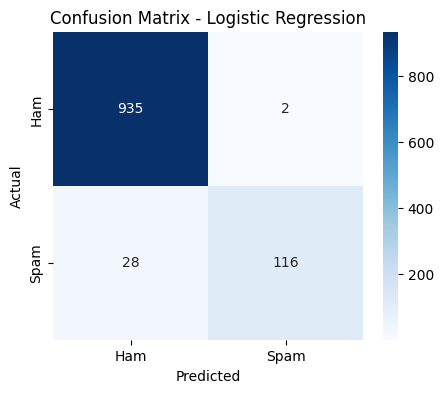

Multinomial Naive Bayes

Accuracy: 96.02%

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       937
        spam       1.00      0.70      0.82       144

    accuracy                           0.96      1081
   macro avg       0.98      0.85      0.90      1081
weighted avg       0.96      0.96      0.96      1081


Confusion Matrix:
[[937   0]
 [ 43 101]]


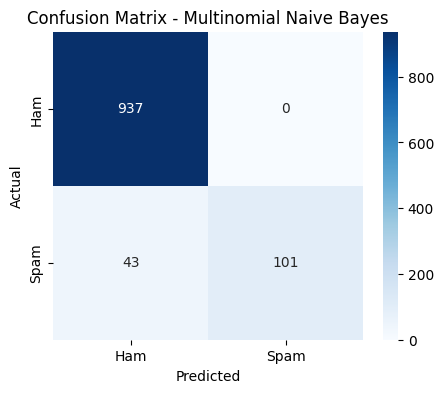

Decision Tree

Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       937
        spam       0.89      0.85      0.87       144

    accuracy                           0.97      1081
   macro avg       0.93      0.92      0.93      1081
weighted avg       0.97      0.97      0.97      1081


Confusion Matrix:
[[922  15]
 [ 21 123]]


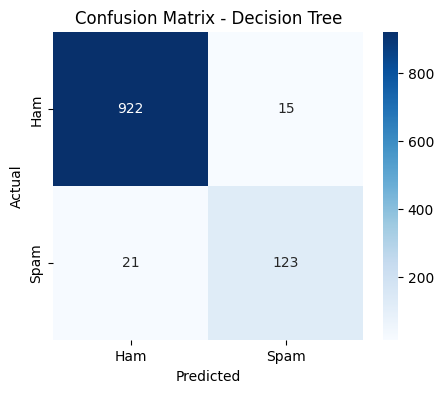

Linear SVC

Accuracy: 98.89%

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       937
        spam       0.99      0.93      0.96       144

    accuracy                           0.99      1081
   macro avg       0.99      0.96      0.98      1081
weighted avg       0.99      0.99      0.99      1081


Confusion Matrix:
[[935   2]
 [ 10 134]]


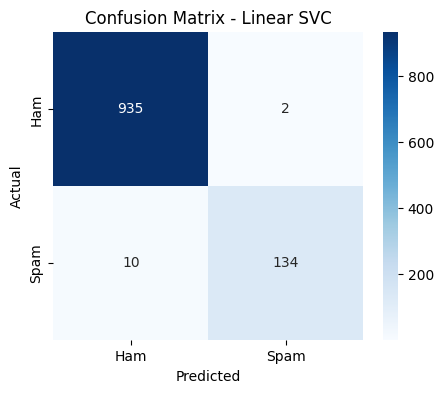

In [35]:
# Train and evaluate each model
for model_name, model in models.items():

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    # Train the model
    model.fit(X_train_tfidf, y_train)

    # Make predictions
    predictions = model.predict(X_test_tfidf)

    # Accuracy
    accuracy = accuracy_score(y_test, predictions)
    # Store model results
    results.append({
    "Model": model_name,
    "Accuracy": accuracy
})


    print(f"\nAccuracy: {accuracy:.2%}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    # Confusion Matrix
    cm = confusion_matrix(y_test, predictions)

    print("\nConfusion Matrix:")
    print(cm)

    # -----------------------------
    # Confusion Matrix Visualization
    # -----------------------------

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Ham", "Spam"],
        yticklabels=["Ham", "Spam"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [36]:
# Create a comparison table
results_df = pd.DataFrame(results)

# Sort by accuracy
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
3,Linear SVC,0.988899
0,Logistic Regression,0.972248
2,Decision Tree,0.966698
1,Multinomial Naive Bayes,0.960222


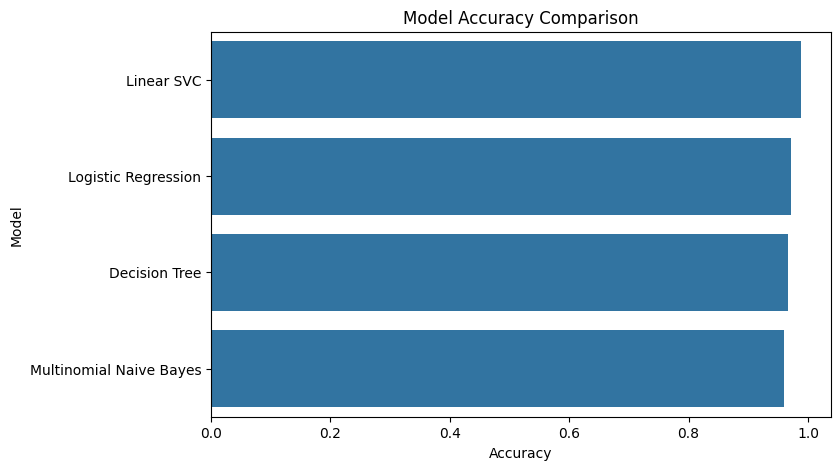

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")

plt.show()

## 11. Comparing Model Performance

To make the comparison easier, we collect the accuracy score of each model
into a summary table.

This allows us to quickly identify which model performs best.

In [38]:
# Create a comparison table
results_df = pd.DataFrame(results)

# Sort by accuracy
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
3,Linear SVC,0.988899
0,Logistic Regression,0.972248
2,Decision Tree,0.966698
1,Multinomial Naive Bayes,0.960222


# 12. Final Conclusion

After comparing all four machine learning models, we observed that each model
performed well in detecting spam messages.

The comparison showed that the best-performing model achieved the highest
accuracy while also maintaining strong precision, recall, and F1-score.

Although accuracy is an important metric, it should not be the only criterion
when evaluating classification models. In spam detection, precision and recall
are equally important because incorrectly classifying legitimate messages as
spam or failing to detect spam messages can negatively affect users.

Based on the obtained results, the selected model provides the best balance
between overall accuracy and reliable spam detection, making it the most
appropriate choice for this task.